In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data.csv')

data.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
data['DateTime'] = pd.to_datetime(data['DateTime'])
data['DateTime'] = pd.to_datetime(data['DateTime'])
data['date'] = data['DateTime'].dt.date
data['time'] = data['DateTime'].dt.time

data.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,date,time
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017-01-01,00:00:00
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017-01-01,00:10:00
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017-01-01,00:20:00
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017-01-01,00:30:00
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017-01-01,00:40:00


In [4]:
data['hour'] = data['DateTime'].dt.hour

data.head(10)

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,date,time,hour
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017-01-01,00:00:00,0
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017-01-01,00:10:00,0
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017-01-01,00:20:00,0
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017-01-01,00:30:00,0
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017-01-01,00:40:00,0
5,2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048,2017-01-01,00:50:00,0
6,2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024,2017-01-01,01:00:00,1
7,2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711,2017-01-01,01:10:00,1
8,2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217,2017-01-01,01:20:00,1
9,2017-01-01 01:30:00,5.491,77.3,0.082,0.062,0.111,24279.49367,15939.20973,16794.21687,2017-01-01,01:30:00,1


In [5]:
print(data.shape)

feature_data = data[['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'hour']]
target_data = data[['Zone 1 Power Consumption']]

print(feature_data.shape)

(52416, 12)
(52416, 6)


In [6]:
    split_point = int(len(feature_data) * 0.75)

    # Train 75%
    train_features = feature_data[:split_point]
    train_target = target_data[:split_point]

    # Test 25%
    test_features = feature_data[split_point:]
    test_target = target_data[split_point:]

In [7]:
def sliding_window(feature_data, target_data, window_size=144, pred_horizon=24, stride=6):

    X = []
    y = []

    position = window_size

    while position + pred_horizon <= len(feature_data):
        window = feature_data[position - window_size : position]

        targets = target_data[position : position + pred_horizon].values.flatten()

        flattened = window.values.flatten()

        X.append(flattened)
        y.append(targets)

        position = position + stride

    return np.array(X), np.array(y)


In [8]:
X_train, y_train = sliding_window(train_features, train_target)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_test, y_test = sliding_window(test_features, test_target)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (6525, 864), y_train: (6525, 24)
X_test: (2157, 864), y_test: (2157, 24)


In [9]:
rmses = []
mapes = []

## LightLGBM regressor

In [10]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

base_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbose=1,
)

model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172896
[LightGBM] [Info] Number of data points in the train set: 6525, number of used features: 864
[LightGBM] [Info] Start training from score 32989.558173
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,estimator,"LGBMRegressor...42, verbose=1)"
,n_jobs,None
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [11]:
y_pred = model.predict(X_test)

C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packag

In [12]:
print(f"y_pred: {y_pred.shape}")
print(f"y_test: {y_test.shape}")

y_pred: (2157, 24)
y_test: (2157, 24)


In [13]:
print(f"\nFirst prediction (24 steps): {y_pred[0]}")
print(f"First actual (24 steps): {y_test[0]}")


First prediction (24 steps): [29506.07204617 29847.81860309 28821.08544063 29004.87209509
 28510.71618632 28209.41108772 27802.07697637 27896.3744577
 27633.00394729 27720.60522203 27363.08318926 26016.69067324
 26637.22724091 25947.73569515 26370.98797587 26055.73734595
 25659.88512236 25232.99974743 25425.47362235 25510.19643239
 25157.92634086 24791.18285599 25544.89109143 26007.21033326]
First actual (24 steps): [30583.45733 29827.22101 29253.74179 28850.41575 28573.1291  28119.38731
 27835.79869 27495.49234 27199.29978 26890.50328 26676.23632 26581.70678
 26348.53392 26140.56893 26348.53392 26146.8709  26134.26696 26046.03939
 25989.32166 25812.86652 25856.98031 25806.56455 25901.09409 25989.32166]


In [14]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmses.append(rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mapes.append(mape)

print(f"RMSE: {rmse}, MAPE: {mape}")

RMSE: 2697.0470397442555, MAPE: 7.231104396988483


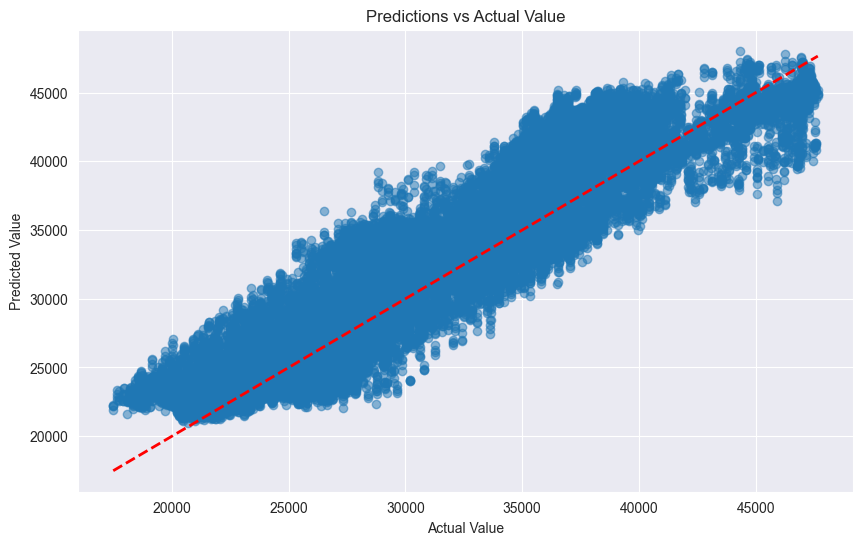

In [15]:
# Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title("Predictions vs Actual Value")
plt.grid(True)
plt.show()

## XGBOOST

In [16]:
from xgboost import XGBRegressor

xgboost_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
)

model = MultiOutputRegressor(xgboost_model)

model.fit(X_train, y_train)


,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None


In [17]:
y_pred = model.predict(X_test)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmses.append(rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mapes.append(mape)

print(f"RMSE: {rmse}, MAPE: {mape}")

RMSE: 2663.078331494727, MAPE: 7.1533852346973905


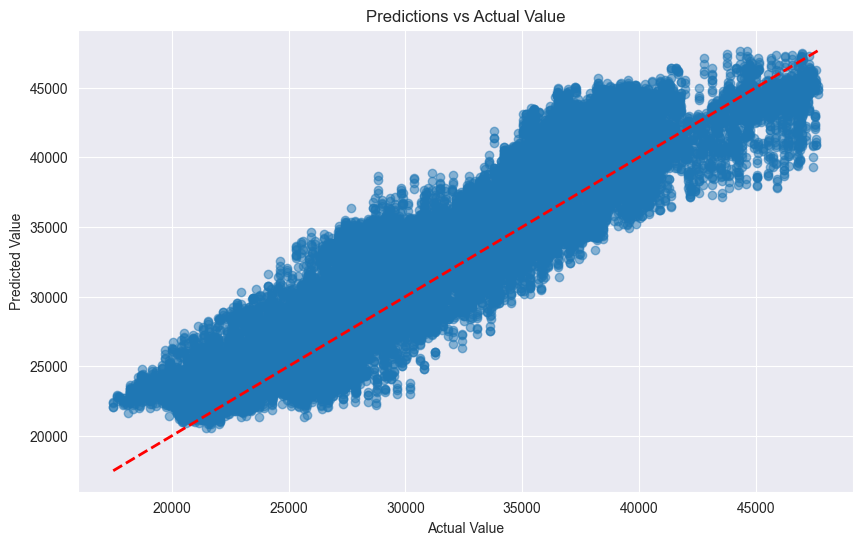

In [19]:
# Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title("Predictions vs Actual Value")
plt.grid(True)
plt.show()

## XGBOOST VS LIGHTGBM

(0.0, 7.954214836687332)

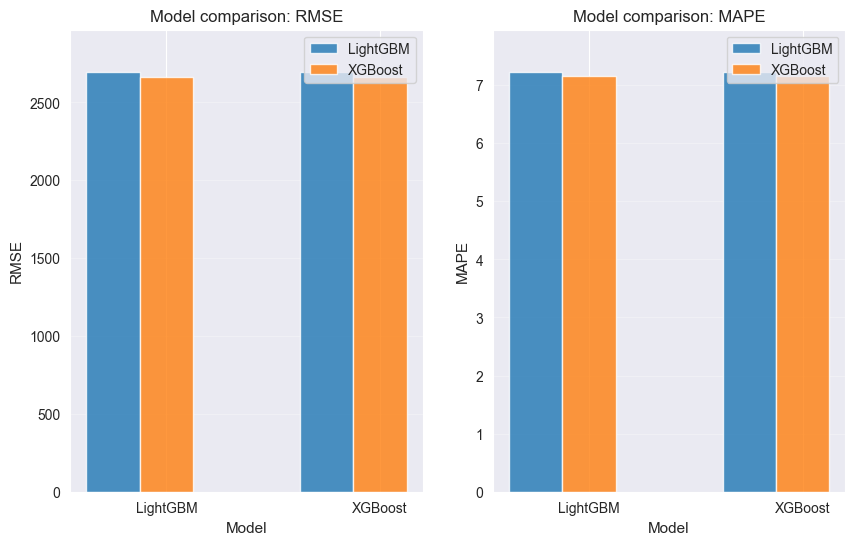

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

model_names = ['LightGBM', 'XGBoost']

x = np.arange(len(model_names))
width = 0.25

# Plot 1: RMSE
axes[0].bar(x - width, rmses[0], width, label=model_names[0], alpha=0.8)
axes[0].bar(x, rmses[1], width, label=model_names[1], alpha=0.8)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Model comparison: RMSE', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(rmses) * 1.1)

# Plot 2: MAPE
axes[1].bar(x - width, mapes[0], width, label=model_names[0], alpha=0.8)
axes[1].bar(x, mapes[1], width, label=model_names[1], alpha=0.8)
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('MAPE', fontsize=11)
axes[1].set_title('Model comparison: MAPE', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(mapes) * 1.1)



XGBoost is just slightly better

## CYCLICAL ENCODING

we will try to boost our models accuracy by using sines and cosines to encode the datetime features

In [21]:
# Hour encoding
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)

# Day of week
data['dayofweek'] = data['DateTime'].dt.dayofweek
data['dow_sin'] = np.sin(2 * np.pi * data['dayofweek'] / 7)
data['dow_cos'] = np.cos(2 * np.pi * data['dayofweek'] / 7)

# Month
data['month'] = data['DateTime'].dt.month
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

In [22]:
data.head()

feature_cols = [
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'Temperature',
    'Humidity',
    'Wind Speed',
    'general diffuse flows',
    'diffuse flows'
]

feature_data = data[feature_cols]
target_data = data['Zone 1 Power Consumption']


In [23]:
split_point = int(len(feature_data) * 0.75)

train_features = feature_data[:split_point]
test_features = feature_data[split_point:]

train_target = target_data[:split_point]
test_target = target_data[split_point:]

In [24]:
X_train, y_train = sliding_window(train_features, train_target, window_size=144, pred_horizon=24, stride=6)

X_test, y_test = sliding_window(test_features, test_target, window_size=144, pred_horizon=24, stride=24)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (6525, 1584)
X_test shape: (540, 1584)


In [25]:
xgboost_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model = MultiOutputRegressor(xgboost_model)

model.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [26]:
y_pred = model.predict(X_test)

In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmses.append(rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mapes.append(mape)

print(f"RMSE: {rmse}, MAPE: {mape}")

RMSE: 3337.177214687291, MAPE: 10.48704672197913


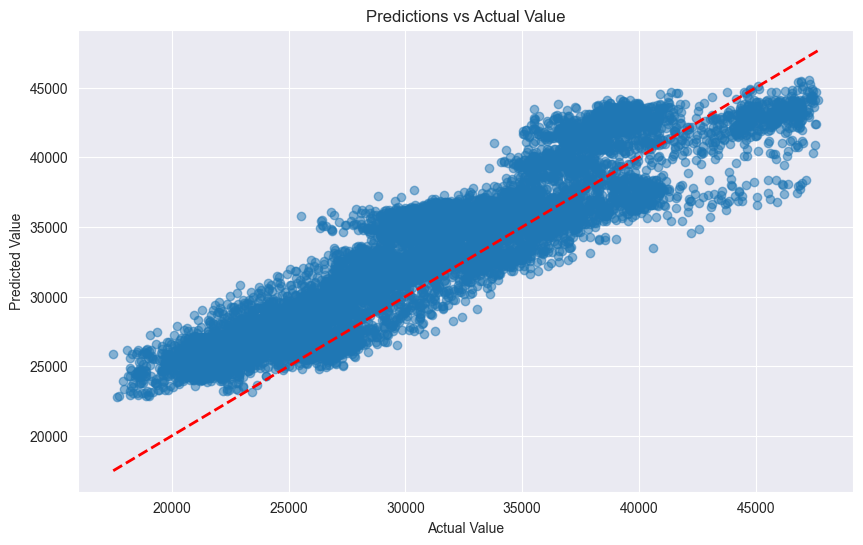

In [28]:
# Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title("Predictions vs Actual Value")
plt.grid(True)
plt.show()

## CATBOOST


In [29]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=False
)

model = MultiOutputRegressor(catboost_model)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmses.append(rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mapes.append(mape)

print(f"RMSE: {rmse}, MAPE: {mape}")

RMSE: 3570.4191838369284, MAPE: 10.803588105361106


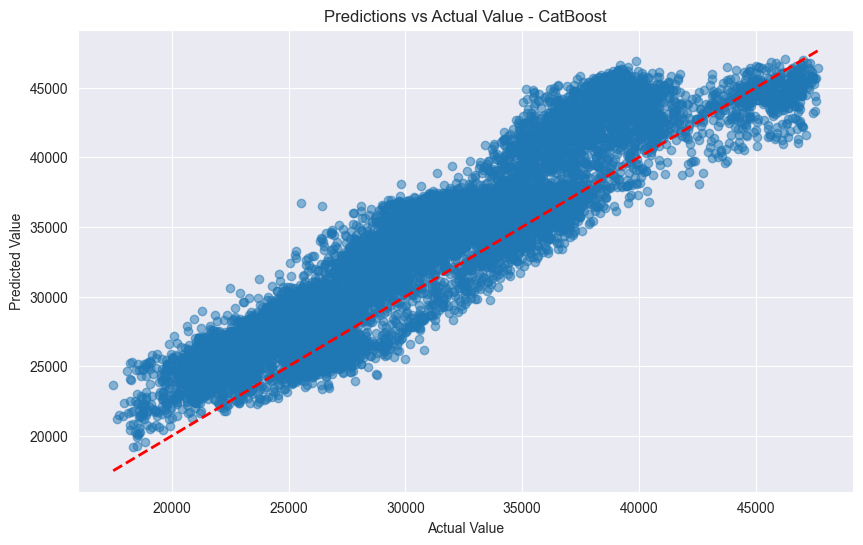

In [30]:
# Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title("Predictions vs Actual Value - CatBoost")
plt.grid(True)
plt.show()

## ALL MODELS COMPARISON

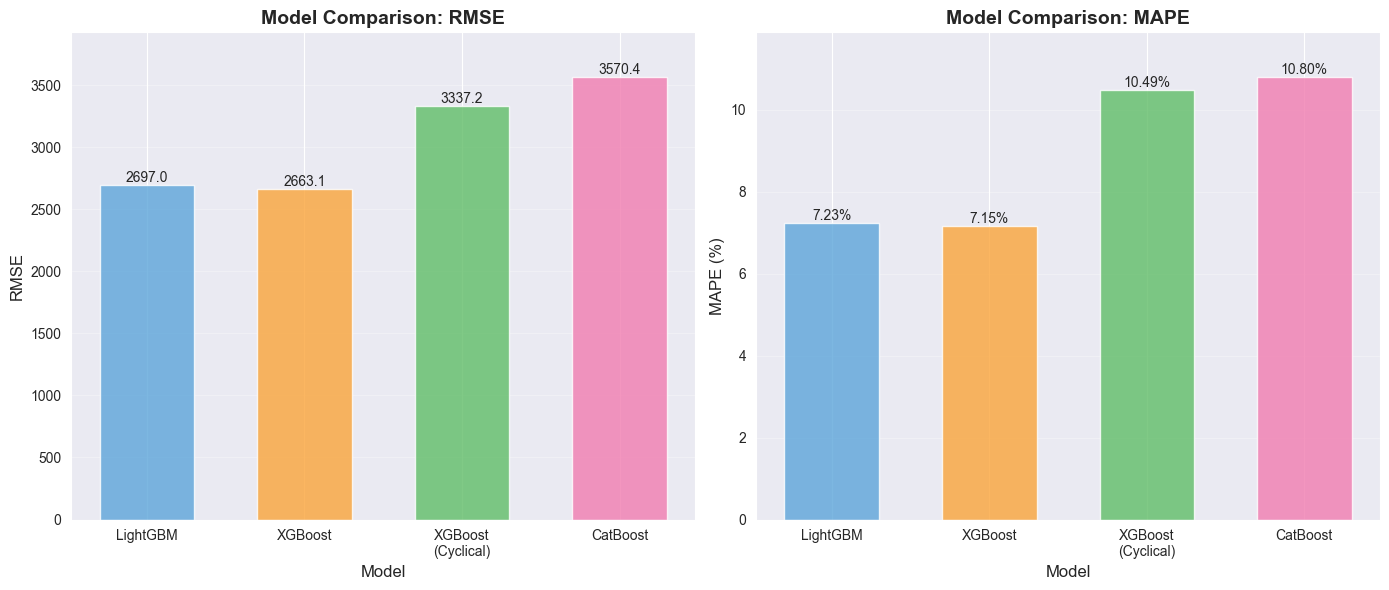

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = ['LightGBM', 'XGBoost', 'XGBoost\n(Cyclical)', 'CatBoost']

x = np.arange(len(model_names))
width = 0.6

# Plot 1: RMSE
bars1 = axes[0].bar(x, rmses, width, alpha=0.8, color=['#5DA5DA', '#FAA43A', '#60BD68', '#F17CB0'])
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('Model Comparison: RMSE', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(rmses) * 1.1)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars1, rmses)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.1f}',
                ha='center', va='bottom', fontsize=10)

# Plot 2: MAPE
bars2 = axes[1].bar(x, mapes, width, alpha=0.8, color=['#5DA5DA', '#FAA43A', '#60BD68', '#F17CB0'])
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('MAPE (%)', fontsize=12)
axes[1].set_title('Model Comparison: MAPE', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(mapes) * 1.1)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars2, mapes)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}%',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [32]:
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"{'Model':<25} {'RMSE':<15} {'MAPE'}")
print("-"*60)
for i, name in enumerate(model_names):
    print(f"{name:<25} {rmses[i]:<15.2f} {mapes[i]:.2f}%")
print("="*60)

best_rmse_idx = np.argmin(rmses)
best_mape_idx = np.argmin(mapes)

print(f"\n🏆 Best RMSE: {model_names[best_rmse_idx]} ({rmses[best_rmse_idx]:.2f})")
print(f"🏆 Best MAPE: {model_names[best_mape_idx]} ({mapes[best_mape_idx]:.2f}%)")


MODEL PERFORMANCE SUMMARY
Model                     RMSE            MAPE
------------------------------------------------------------
LightGBM                  2697.05         7.23%
XGBoost                   2663.08         7.15%
XGBoost
(Cyclical)        3337.18         10.49%
CatBoost                  3570.42         10.80%

🏆 Best RMSE: XGBoost (2663.08)
🏆 Best MAPE: XGBoost (7.15%)


## XGBOOST WITH CYCLICAL ENCODING (ALL ZONES)

In [35]:
zones = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']

zone_results = {}

for zone_name in zones:
    print(f"\n{'='*60}")
    print(f"Training model for: {zone_name}")
    print(f"{'='*60}")

    target_data = data[zone_name]

    train_target = target_data[:split_point]
    test_target = target_data[split_point:]

    print("Creating sliding windows...")
    X_train, y_train = sliding_window(train_features, train_target,
                                       window_size=144, pred_horizon=24, stride=6)
    X_test, y_test = sliding_window(test_features, test_target,
                                     window_size=144, pred_horizon=24, stride=24)

    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    print("Training XGBoost model...")
    xgboost_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

    model = MultiOutputRegressor(xgboost_model)
    model.fit(X_train, y_train)

    print("Making predictions...")
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    zone_results[zone_name] = {
        'model': model,
        'y_test': y_test,
        'y_pred': y_pred,
        'rmse': rmse,
        'mape': mape
    }

    print(f"\nResults for {zone_name}:")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   MAPE: {mape:.2f}%")


Training model for: Zone 1 Power Consumption
Creating sliding windows...
X_train shape: (6525, 1584), y_train shape: (6525, 24)
X_test shape: (540, 1584), y_test shape: (540, 24)
Training XGBoost model...
Making predictions...

Results for Zone 1 Power Consumption:
   RMSE: 3123.05
   MAPE: 8.98%

Training model for: Zone 2  Power Consumption
Creating sliding windows...
X_train shape: (6525, 1584), y_train shape: (6525, 24)
X_test shape: (540, 1584), y_test shape: (540, 24)
Training XGBoost model...
Making predictions...

Results for Zone 2  Power Consumption:
   RMSE: 3189.51
   MAPE: 10.90%

Training model for: Zone 3  Power Consumption
Creating sliding windows...
X_train shape: (6525, 1584), y_train shape: (6525, 24)
X_test shape: (540, 1584), y_test shape: (540, 24)
Training XGBoost model...
Making predictions...

Results for Zone 3  Power Consumption:
   RMSE: 6146.57
   MAPE: 47.27%



SUMMARY: ALL ZONES PREDICTION PERFORMANCE
Zone                           RMSE                 MAPE
----------------------------------------------------------------------
Zone 1 Power Consumption       3123.05              8.98%
Zone 2  Power Consumption      3189.51              10.90%
Zone 3  Power Consumption      6146.57              47.27%
----------------------------------------------------------------------
AVERAGE                        4153.04              22.38%


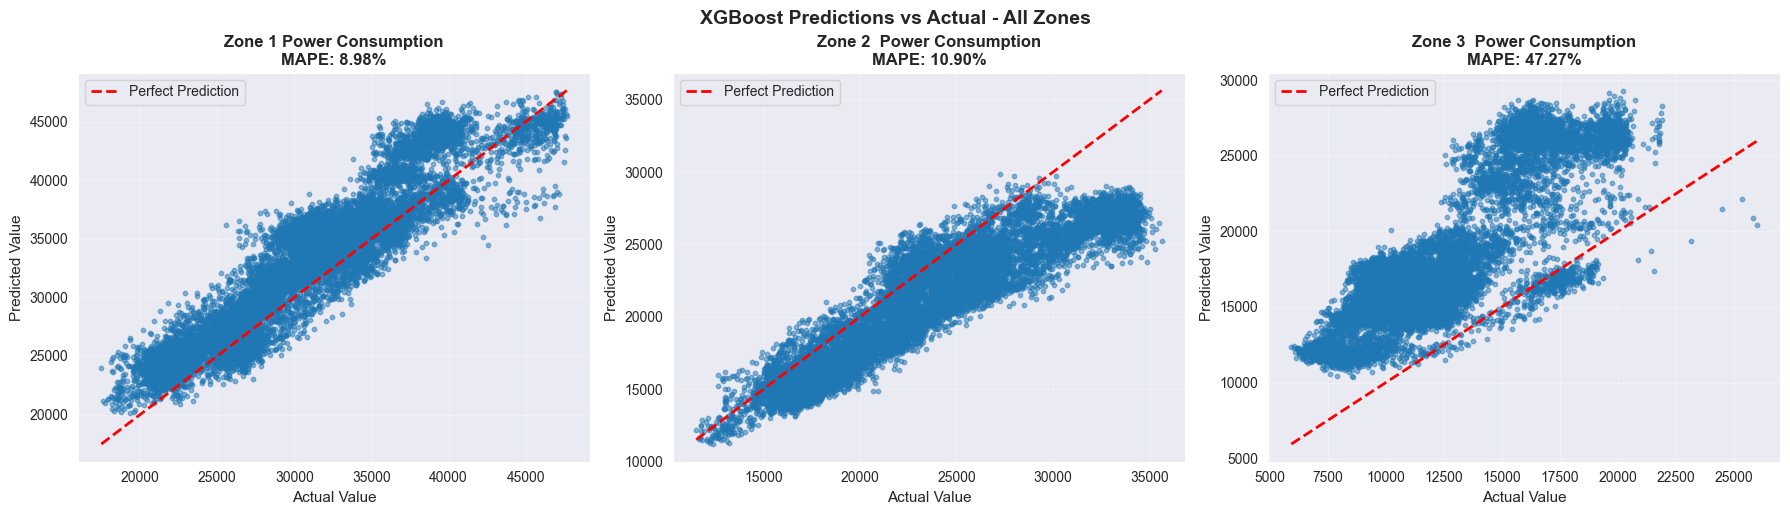

In [36]:
print("\n" + "=" * 70)
print("SUMMARY: ALL ZONES PREDICTION PERFORMANCE")
print("=" * 70)
print(f"{'Zone':<30} {'RMSE':<20} {'MAPE'}")
print("-" * 70)

total_rmse = 0
total_mape = 0

for zone_name in zones:
    rmse = zone_results[zone_name]['rmse']
    mape = zone_results[zone_name]['mape']
    total_rmse += rmse
    total_mape += mape
    print(f"{zone_name:<30} {rmse:<20.2f} {mape:.2f}%")

avg_rmse = total_rmse / len(zones)
avg_mape = total_mape / len(zones)

print("-" * 70)
print(f"{'AVERAGE':<30} {avg_rmse:<20.2f} {avg_mape:.2f}%")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, zone_name in enumerate(zones):
    y_test = zone_results[zone_name]['y_test']
    y_pred = zone_results[zone_name]['y_pred']
    mape = zone_results[zone_name]['mape']

    axes[idx].scatter(y_test, y_pred, alpha=0.5, s=10)
    axes[idx].plot([y_test.min(), y_test.max()],
                   [y_test.min(), y_test.max()],
                   'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Value', fontsize=11)
    axes[idx].set_ylabel('Predicted Value', fontsize=11)
    axes[idx].set_title(f'{zone_name}\nMAPE: {mape:.2f}%', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.suptitle('XGBoost Predictions vs Actual - All Zones',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

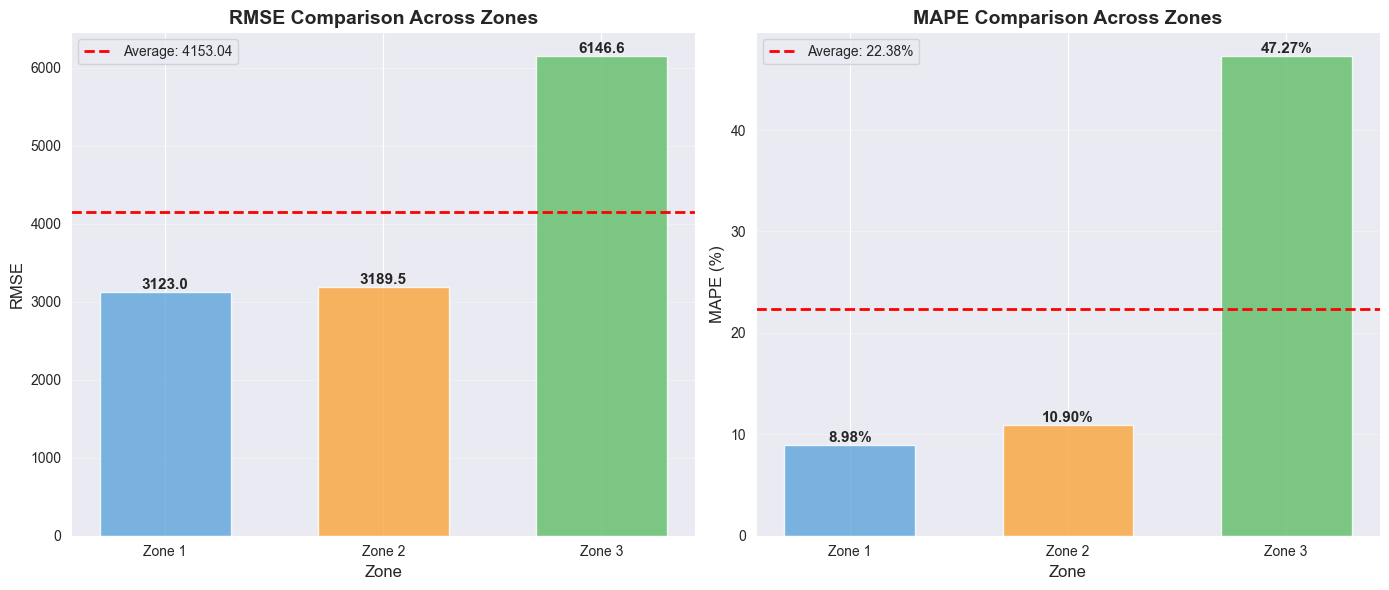


PREDICTION ERROR BY TIME HORIZON (Average across all zones)
Time Ahead           Average MAPE
----------------------------------------------------------------------
10 minutes (1 steps):<20 23.07%
50 minutes (5 steps):<20 21.31%
90 minutes (9 steps):<20 20.95%
130 minutes (13 steps):<20 21.73%
170 minutes (17 steps):<20 22.95%
210 minutes (21 steps):<20 22.92%


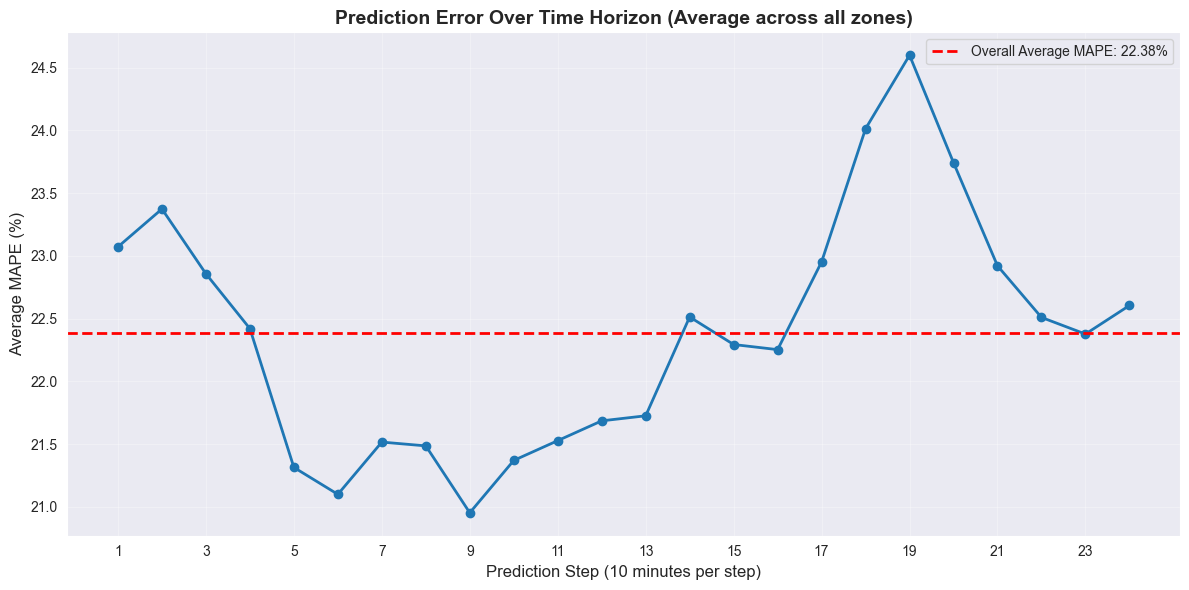

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

zone_names_short = ['Zone 1', 'Zone 2', 'Zone 3']
rmse_values = [zone_results[z]['rmse'] for z in zones]
mape_values = [zone_results[z]['mape'] for z in zones]

x = np.arange(len(zone_names_short))
width = 0.6

# RMSE
bars1 = axes[0].bar(x, rmse_values, width, alpha=0.8,
                    color=['#5DA5DA', '#FAA43A', '#60BD68'])
axes[0].set_xlabel('Zone', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('RMSE Comparison Across Zones', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(zone_names_short)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=avg_rmse, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_rmse:.2f}')
axes[0].legend()

for bar, value in zip(bars1, rmse_values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2., height,
                 f'{value:.1f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# MAPE
bars2 = axes[1].bar(x, mape_values, width, alpha=0.8,
                    color=['#5DA5DA', '#FAA43A', '#60BD68'])
axes[1].set_xlabel('Zone', fontsize=12)
axes[1].set_ylabel('MAPE (%)', fontsize=12)
axes[1].set_title('MAPE Comparison Across Zones', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(zone_names_short)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=avg_mape, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_mape:.2f}%')
axes[1].legend()

for bar, value in zip(bars2, mape_values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2., height,
                 f'{value:.2f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze prediction error over time horizon (first 24 steps)
print("\n" + "=" * 70)
print("PREDICTION ERROR BY TIME HORIZON (Average across all zones)")
print("=" * 70)

# Average MAPE for each of the 24 prediction steps across all zones
avg_step_mape = np.zeros(24)

for zone_name in zones:
    y_test = zone_results[zone_name]['y_test']
    y_pred = zone_results[zone_name]['y_pred']

    for i in range(24):
        step_error = np.mean(np.abs((y_test[:, i] - y_pred[:, i]) / y_test[:, i])) * 100
        avg_step_mape[i] += step_error

avg_step_mape /= len(zones)

print(f"{'Time Ahead':<20} {'Average MAPE'}")
print("-" * 70)
for i in range(0, 24, 4):
    minutes_ahead = (i + 1) * 10
    print(f"{minutes_ahead} minutes ({(i + 1)} steps):<20 {avg_step_mape[i]:.2f}%")
print("=" * 70)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), avg_step_mape, marker='o', linewidth=2, markersize=6)
plt.xlabel('Prediction Step (10 minutes per step)', fontsize=12)
plt.ylabel('Average MAPE (%)', fontsize=12)
plt.title('Prediction Error Over Time Horizon (Average across all zones)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 25, 2))
plt.axhline(y=avg_mape, color='red', linestyle='--', linewidth=2,
            label=f'Overall Average MAPE: {avg_mape:.2f}%')
plt.legend()
plt.tight_layout()
plt.show()

BASIC STATISTICS FOR ALL ZONES

Zone 1 Power Consumption:
  Mean:     32344.97
  Std Dev:  7130.56
  Min:      13895.70
  Max:      52204.40
  Median:   32265.92
  CV (Coefficient of Variation): 0.22

Zone 2  Power Consumption:
  Mean:     21042.51
  Std Dev:  5201.47
  Min:      8560.08
  Max:      37408.86
  Median:   20823.17
  CV (Coefficient of Variation): 0.25

Zone 3  Power Consumption:
  Mean:     17835.41
  Std Dev:  6622.17
  Min:      5935.17
  Max:      47598.33
  Median:   16415.12
  CV (Coefficient of Variation): 0.37


C:\Users\galek\AppData\Local\Temp\ipykernel_9812\3424090153.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot(zone_data_list, labels=['Zone 1', 'Zone 2', 'Zone 3'])


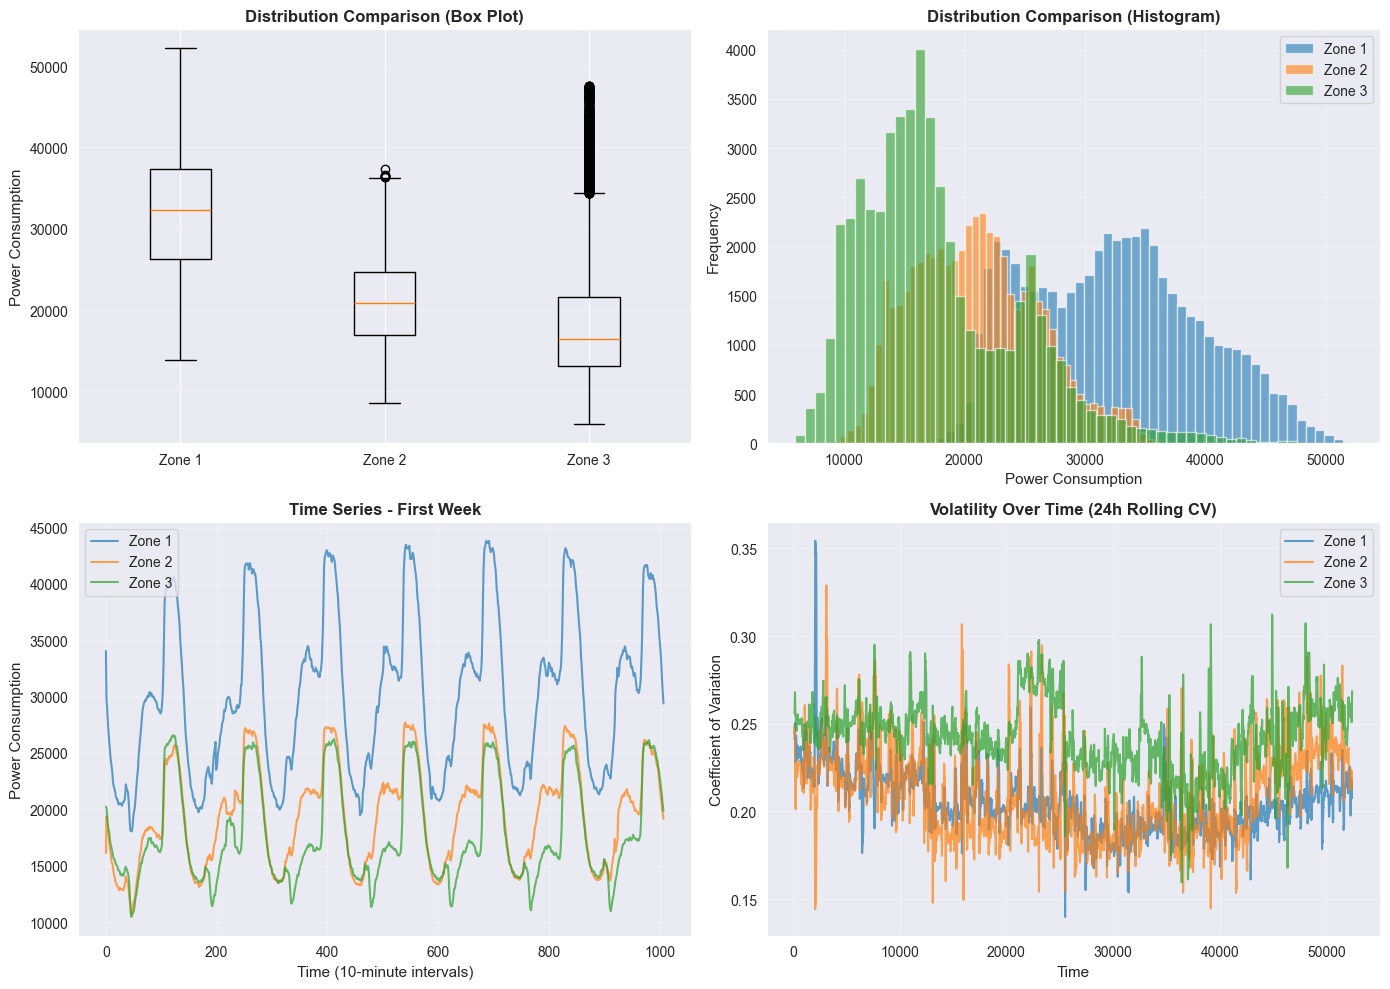


ANOMALY DETECTION - ZONE 3
Zero values: 0
Near-zero values (<100): 0
High outliers (>3σ): 653
Low outliers (<-3σ): 0

Values below 10th percentile (10490.60): 5238 (10.0%)

ZONE 3 PREDICTION ANALYSIS

First 5 predictions vs actuals:
Sample 1: Actual avg=12723.9, Predicted avg=15023.8, Error=18.1%
Sample 2: Actual avg=10636.4, Predicted avg=13173.2, Error=23.9%
Sample 3: Actual avg=11424.0, Predicted avg=14999.7, Error=31.3%
Sample 4: Actual avg=13118.5, Predicted avg=17064.9, Error=30.1%
Sample 5: Actual avg=16415.3, Predicted avg=20875.4, Error=27.2%

Actual values range: 5935.2 to 25972.0
Predicted values range: 10402.6 to 29317.9

Actual mean: 12387.1
Predicted mean: 17933.6


In [39]:
print("=" * 70)
print("BASIC STATISTICS FOR ALL ZONES")
print("=" * 70)

for zone_name in zones:
    zone_data = data[zone_name]
    print(f"\n{zone_name}:")
    print(f"  Mean:     {zone_data.mean():.2f}")
    print(f"  Std Dev:  {zone_data.std():.2f}")
    print(f"  Min:      {zone_data.min():.2f}")
    print(f"  Max:      {zone_data.max():.2f}")
    print(f"  Median:   {zone_data.median():.2f}")
    print(f"  CV (Coefficient of Variation): {(zone_data.std() / zone_data.mean()):.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Box plots
zone_data_list = [data[zone] for zone in zones]
axes[0, 0].boxplot(zone_data_list, labels=['Zone 1', 'Zone 2', 'Zone 3'])
axes[0, 0].set_ylabel('Power Consumption', fontsize=11)
axes[0, 0].set_title('Distribution Comparison (Box Plot)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Histograms
for idx, zone_name in enumerate(zones):
    axes[0, 1].hist(data[zone_name], bins=50, alpha=0.6,
                    label=f'Zone {idx + 1}')
axes[0, 1].set_xlabel('Power Consumption', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution Comparison (Histogram)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Time series - first week
first_week = data[:1008]  # First week (7 days * 144 intervals)
for idx, zone_name in enumerate(zones):
    axes[1, 0].plot(first_week[zone_name], label=f'Zone {idx + 1}', alpha=0.7)
axes[1, 0].set_xlabel('Time (10-minute intervals)', fontsize=11)
axes[1, 0].set_ylabel('Power Consumption', fontsize=11)
axes[1, 0].set_title('Time Series - First Week', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Coefficient of variation over time (rolling)
window = 144
for idx, zone_name in enumerate(zones):
    rolling_mean = data[zone_name].rolling(window=window).mean()
    rolling_std = data[zone_name].rolling(window=window).std()
    cv = rolling_std / rolling_mean
    axes[1, 1].plot(cv, label=f'Zone {idx + 1}', alpha=0.7)
axes[1, 1].set_xlabel('Time', fontsize=11)
axes[1, 1].set_ylabel('Coefficient of Variation', fontsize=11)
axes[1, 1].set_title('Volatility Over Time (24h Rolling CV)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ANOMALY DETECTION - ZONE 3")
print("=" * 70)

zone3_data = data['Zone 3  Power Consumption']

# Check for zeros or near-zeros
zeros = (zone3_data == 0).sum()
near_zeros = (zone3_data < 100).sum()
print(f"Zero values: {zeros}")
print(f"Near-zero values (<100): {near_zeros}")

# Check for extreme outliers
mean = zone3_data.mean()
std = zone3_data.std()
outliers_high = (zone3_data > mean + 3 * std).sum()
outliers_low = (zone3_data < mean - 3 * std).sum()
print(f"High outliers (>3σ): {outliers_high}")
print(f"Low outliers (<-3σ): {outliers_low}")

# Check percentage of very low values
low_threshold = zone3_data.quantile(0.1)
very_low_count = (zone3_data < low_threshold).sum()
print(
    f"\nValues below 10th percentile ({low_threshold:.2f}): {very_low_count} ({very_low_count / len(zone3_data) * 100:.1f}%)")

print("\n" + "=" * 70)
print("ZONE 3 PREDICTION ANALYSIS")
print("=" * 70)

y_test_z3 = zone_results['Zone 3  Power Consumption']['y_test']
y_pred_z3 = zone_results['Zone 3  Power Consumption']['y_pred']

print("\nFirst 5 predictions vs actuals:")
for i in range(5):
    actual_avg = y_test_z3[i].mean()
    pred_avg = y_pred_z3[i].mean()
    error_pct = abs(actual_avg - pred_avg) / actual_avg * 100
    print(f"Sample {i + 1}: Actual avg={actual_avg:.1f}, Predicted avg={pred_avg:.1f}, Error={error_pct:.1f}%")

print(f"\nActual values range: {y_test_z3.min():.1f} to {y_test_z3.max():.1f}")
print(f"Predicted values range: {y_pred_z3.min():.1f} to {y_pred_z3.max():.1f}")
print(f"\nActual mean: {y_test_z3.mean():.1f}")
print(f"Predicted mean: {y_pred_z3.mean():.1f}")

In [40]:
## IMPROVING ZONE 3 WITH LAG FEATURES
# Create lag features specifically for Zone 3
# Add yesterday's consumption at the same time (144 steps = 24 hours ago)

data['zone3_lag_24h'] = data['Zone 3  Power Consumption'].shift(144)
data['zone3_lag_48h'] = data['Zone 3  Power Consumption'].shift(288)

# Add rolling averages
data['zone3_rolling_mean_24h'] = data['Zone 3  Power Consumption'].rolling(window=144).mean()

data_clean = data.dropna()


feature_cols_zone3 = [
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'Temperature',
    'Humidity',
    'Wind Speed',
    'general diffuse flows',
    'diffuse flows',
    'zone3_lag_24h',
    'zone3_lag_48h',
    'zone3_rolling_mean_24h'
]

feature_data_zone3 = data_clean[feature_cols_zone3]
target_data_zone3 = data_clean['Zone 3  Power Consumption']

split_point_zone3 = int(len(feature_data_zone3) * 0.75)

train_features_z3 = feature_data_zone3[:split_point_zone3]
test_features_z3 = feature_data_zone3[split_point_zone3:]

train_target_z3 = target_data_zone3[:split_point_zone3]
test_target_z3 = target_data_zone3[split_point_zone3:]

X_train_z3, y_train_z3 = sliding_window(train_features_z3, train_target_z3,
                                        window_size=144, pred_horizon=24, stride=6)
X_test_z3, y_test_z3 = sliding_window(test_features_z3, test_target_z3,
                                      window_size=144, pred_horizon=24, stride=24)

print(f"X_train_z3 shape: {X_train_z3.shape}")
print(f"X_test_z3 shape: {X_test_z3.shape}")

print("\nTraining improved Zone 3 model with lag features...")
xgboost_z3 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model_z3 = MultiOutputRegressor(xgboost_z3)
model_z3.fit(X_train_z3, y_train_z3)

y_pred_z3_improved = model_z3.predict(X_test_z3)

rmse_z3_improved = np.sqrt(mean_squared_error(y_test_z3, y_pred_z3_improved))
mape_z3_improved = np.mean(np.abs((y_test_z3 - y_pred_z3_improved) / y_test_z3)) * 100

print(f"\n{'=' * 60}")
print("ZONE 3 IMPROVEMENT COMPARISON")
print(f"{'=' * 60}")
print(f"Original Model:")
print(f"  RMSE: {zone_results['Zone 3  Power Consumption']['rmse']:.2f}")
print(f"  MAPE: {zone_results['Zone 3  Power Consumption']['mape']:.2f}%")
print(f"\nImproved Model (with lag features):")
print(f"  RMSE: {rmse_z3_improved:.2f}")
print(f"  MAPE: {mape_z3_improved:.2f}%")
print(f"\nImprovement:")
print(f"  RMSE: {zone_results['Zone 3  Power Consumption']['rmse'] - rmse_z3_improved:.2f} better")
print(f"  MAPE: {zone_results['Zone 3  Power Consumption']['mape'] - mape_z3_improved:.2f}% better")
print(f"{'=' * 60}")

X_train_z3 shape: (6489, 2016)
X_test_z3 shape: (537, 2016)

Training improved Zone 3 model with lag features...

ZONE 3 IMPROVEMENT COMPARISON
Original Model:
  RMSE: 6146.57
  MAPE: 47.27%

Improved Model (with lag features):
  RMSE: 1375.01
  MAPE: 8.72%

Improvement:
  RMSE: 4771.56 better
  MAPE: 38.55% better
